## pyRofex - Pandas - Sklearn ##

Objetivo es hacer una prediccion del precio de la soja rosario para la los proximos 30 dias , tomando como dato el precio de soja rosario y entrenano el modelo para haga la prediccion . 

Para ello hay crear un usuario en pyRofex para poder ingresar al api del Rofex y obtener el dato del precio en soja disponible en pesos ("SOJ.ROS.P/DISPO" ) desde el 1/1/1/2025 a hoy . 

Despues los ponemos los dato en Pandas datafrema para procesar los datos . 

Guardo los datos en excel para tenerlos disponible si hoy conseguimos acceso al API .



In [35]:
import pandas as pd
import datetime
import pyRofex

end = datetime.date.today()
start = datetime.date(year=2025, month=1, day=1)
result=pd.DataFrame()## Data Frame Vacio
instrument = "SOJ.ROS.P/DISPO"  ## Instrumento a consultar

pyRofex.initialize(user="nperezchena21328",
                   password="ibghwY5$",
                   account="REM21328",
                   environment=pyRofex.Environment.REMARKET)

ht = pyRofex.get_trade_history(ticker=instrument, start_date=start, end_date=end)
print(ht)
#print(type(ht))
tr=ht["trades"]
ptr=pd.DataFrame(tr,columns=["symbol","size","price","datetime"])
print(ptr)
ptr["dia"]= pd.to_datetime(ptr["datetime"].str[:10], format='%Y-%m-%d') ## Creo columan dia
ptr=ptr.drop(['datetime'], axis=1)  ##Saco columna datetiem
ptr=ptr.set_index("dia")
ptr=ptr.groupby(by=["dia"]).agg({'size':'sum', 'price': 'max'})
#ptr = ptr.groupby(by=["dia"]).agg({'size': 'sum', 'price': 'mean'})
ptr=ptr.drop(['size'], axis=1)  ##Saco columna datetie
print(ptr)

{'status': 'OK', 'symbol': 'SOJ.ROS.P/DISPO', 'market': 'ROFX', 'trades': [{'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1735929696914, 'size': 3.0, 'price': 285000.0, 'datetime': '2025-01-03 18:41:36.914'}, {'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1735931670661, 'size': 1.0, 'price': 285000.0, 'datetime': '2025-01-03 19:14:30.661'}, {'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1735934290454, 'size': 1.0, 'price': 285000.0, 'datetime': '2025-01-03 19:58:10.454'}, {'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1736527415469, 'size': 4.0, 'price': 290000.0, 'datetime': '2025-01-10 16:43:35.469'}, {'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1736798392889, 'size': 4.0, 'price': 298000.0, 'datetime': '2025-01-13 19:59:52.889'}, {'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1736798392889, 'size': 10.0, 'price': 298000.0, 'datetime': '2025-01-13 19:59:52.889'}, {'symbol': 'SOJ.ROS.P/DISPO', 'servertime': 1737056965610, 'size': 3.0, 'price': 288000.0, 'datetime': '2025-01-16 19:49:25.610'}, {'symbo

In [36]:
print(ptr.head())  ## Muestro las primeras filas del DataFrame      

               price
dia                 
2025-01-03  285000.0
2025-01-10  290000.0
2025-01-13  298000.0
2025-01-16  290000.0
2025-01-17  290000.0


In [37]:
ptr.to_excel("SOJDISPO25.xlsx", index=True)  ## Exporto a Excel

In [42]:
import pandas as pd
ptr= pd.read_excel("SOJDISPO25.xlsx", sheet_name="Sheet1")  ## Leo el Excel
ptroriginal=ptr.copy()  ## Copio el DataFrame original

Vamos Ingresar los Datos en Sklearn para entrenar 

In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Seleccionar los precios de un contrato específico (por ejemplo, MAY25)
precio_columna = "price"
ptr["dia"] = np.arange(len(ptr))  # Convertir la fecha en números secuenciales

# Entrenar el modelo de regresión lineal
X = ptr[["dia"]]
y = ptr[precio_columna]
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [45]:
dias_futuros = np.arange(len(ptr), len(ptr) + 30 ).reshape(-1, 1)
predicciones = modelo.predict(dias_futuros)
print(predicciones)  # Mostrar las predicciones para los próximos 7 días

nuevos_dias_futuros = pd.DataFrame(np.arange(len(ptroriginal), len(ptroriginal) + 30), columns=["dia"])
nuevas_predicciones = modelo.predict(nuevos_dias_futuros)
print(nuevas_predicciones)  # Mostrar las predicciones para los próximos 7 días


[331585.74660633 332022.14633313 332458.54605993 332894.94578673
 333331.34551353 333767.74524033 334204.14496713 334640.54469393
 335076.94442073 335513.34414753 335949.74387433 336386.14360113
 336822.54332793 337258.94305473 337695.34278152 338131.74250832
 338568.14223512 339004.54196192 339440.94168872 339877.34141552
 340313.74114232 340750.14086912 341186.54059592 341622.94032272
 342059.34004952 342495.73977632 342932.13950312 343368.53922992
 343804.93895671 344241.33868351]
[331585.74660633 332022.14633313 332458.54605993 332894.94578673
 333331.34551353 333767.74524033 334204.14496713 334640.54469393
 335076.94442073 335513.34414753 335949.74387433 336386.14360113
 336822.54332793 337258.94305473 337695.34278152 338131.74250832
 338568.14223512 339004.54196192 339440.94168872 339877.34141552
 340313.74114232 340750.14086912 341186.54059592 341622.94032272
 342059.34004952 342495.73977632 342932.13950312 343368.53922992
 343804.93895671 344241.33868351]


c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2025\SGDPV\Ejercicios\Profe\Clase 27-5\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


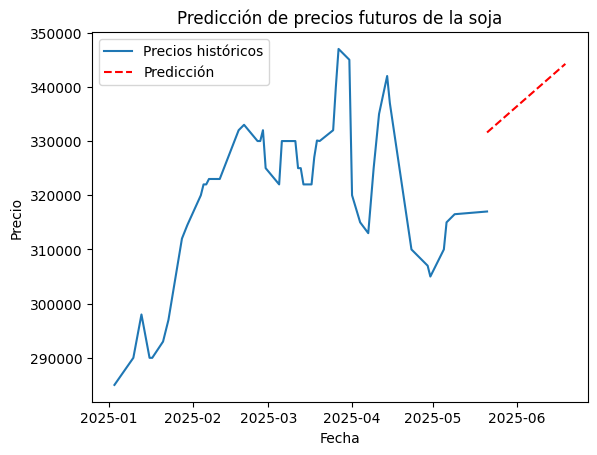

In [46]:
import matplotlib.pyplot as plt

# Graficar resultados
plt.plot(ptroriginal["dia"], y, label="Precios históricos")
plt.plot(pd.date_range(ptroriginal["dia"].iloc[-1], periods=30, freq="D"), predicciones, "r--", label="Predicción")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.title("Predicción de precios futuros de la soja")
plt.legend()
plt.show()